# CDR3 Sequence Logos and Motif Analysis

This notebook demonstrates the `mir.biomarkers.motif_logo` module:

1. **Position-weight matrix (PWM)** — per-position amino-acid frequency from CDR3 sequences.
2. **Standard IC logo** — letter heights ∝ Shannon information content (Schneider *et al.* 1986; Schneider & Stephens 1990).
3. **Background-normalised logo** — log-odds heights relative to OLGA-derived synthetic background
   for the same V-gene / J-gene / length combination (Pogorelyy *et al.* 2019, VDJdb-motifs).

Two biological examples are explored:

* **GILGFVFTL** (Influenza A, HLA-A\*02) — the largest TRB motif cluster in VDJdb, dominated by
  TRBV19 and a conserved **RS** motif.
* **Ankylosing Spondylitis (HLA-B27)** — CASSVGL[YF]STDTQYF sequences (TRBV9/TRBJ2-3)
  identified by ALICE from synovial fluid CD8+ repertoires (Pogorelyy *et al.* 2019,
  *eBioMedicine* 43, 545–553).

**References**
- Pogorelyy *et al.* (2019) https://doi.org/10.1016/j.ebiom.2019.04.050
- Schneider *et al.* (1986) *J. Mol. Biol.* 188, 415 — IC formula
- Schneider & Stephens (1990) *Nucleic Acids Res.* 18, 6097 — logo visualization
- VDJdb-motifs: https://github.com/antigenomics/vdjdb-motifs
- OLGA: https://github.com/statbiophys/OLGA

In [1]:
"""Cell 1: Environment setup."""
import sys
import time
import importlib.metadata
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

from mir.biomarkers.motif_logo import (
    compute_pwm,
    compute_logo,
    load_motif_pwms,
    pwm_from_motif_pwms,
    get_vj_background,
    plot_logo,
    plot_motif_logos,
    compute_cluster_profiles,
)
from mir.utils.notebook_assets import (
    ensure_airr_benchmark,
    find_airr_benchmark_motif_pwms,
    find_airr_benchmark_vdjdb_slim,
    find_repo_root,
)

# Notebook-wide settings
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 9,
    'axes.labelsize': 9,
})

print(f"Python  {sys.version.split()[0]}")
print(f"polars  {pl.__version__}")
print(f"matplotlib  {matplotlib.__version__}")
print(f"numpy   {np.__version__}")

/Users/mikesh/vcs/mirpy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python  3.12.12
polars  1.40.1
matplotlib  3.10.9
numpy   1.26.4


In [2]:
"""Cell 2: Bootstrap VDJdb assets (motif_pwms + VDJdb slim)."""
REPO_ROOT = find_repo_root()
DATASET_ROOT = ensure_airr_benchmark(repo_root=REPO_ROOT, allow_patterns=["vdjdb/**"])
MOTIF_PWMS_PATH = find_airr_benchmark_motif_pwms(DATASET_ROOT)
VDJDB_SLIM_PATH = find_airr_benchmark_vdjdb_slim(DATASET_ROOT)

print(f"motif_pwms : {MOTIF_PWMS_PATH}")
print(f"vdjdb slim : {VDJDB_SLIM_PATH}")

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 1548.00it/s]

motif_pwms : /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark/vdjdb/vdjdb-2025-12-29/motif_pwms.txt.gz
vdjdb slim : /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark/vdjdb/vdjdb-2025-12-29/vdjdb.slim.txt.gz


In [3]:
"""Cell 3: Load motif_pwms and VDJdb."""
motif_pwms = load_motif_pwms(MOTIF_PWMS_PATH)

# VDJdb slim for extracting raw CDR3 sequences
import gzip
with gzip.open(VDJDB_SLIM_PATH, 'rb') as fh:
    vdjdb = pl.read_csv(fh, separator='\t', infer_schema_length=10_000)

print(f"motif_pwms: {motif_pwms.shape[0]:,} rows, {motif_pwms.shape[1]} columns")
print(f"vdjdb     : {len(vdjdb):,} rows")
print()

# Summarise available motif clusters
cluster_summary = (
    motif_pwms
    .select(['cid', 'csz', 'species', 'gene', 'antigen.epitope', 'v.segm.repr', 'j.segm.repr', 'len'])
    .unique()
    .sort('csz', descending=True)
)
print("Top 10 motif clusters by size:")
print(cluster_summary.head(10))

motif_pwms: 23,448 rows, 27 columns
vdjdb     : 145,408 rows

Top 10 motif clusters by size:
shape: (10, 8)
┌─────────────────┬───────┬─────────────┬──────┬─────────────────┬─────────────┬─────────────┬─────┐
│ cid             ┆ csz   ┆ species     ┆ gene ┆ antigen.epitope ┆ v.segm.repr ┆ j.segm.repr ┆ len │
│ ---             ┆ ---   ┆ ---         ┆ ---  ┆ ---             ┆ ---         ┆ ---         ┆ --- │
│ str             ┆ i64   ┆ str         ┆ str  ┆ str             ┆ str         ┆ str         ┆ i64 │
╞═════════════════╪═══════╪═════════════╪══════╪═════════════════╪═════════════╪═════════════╪═════╡
│ H.B.SLLMWITQV.1 ┆ 19972 ┆ HomoSapiens ┆ TRB  ┆ SLLMWITQV       ┆ TRBV6-5*01  ┆ TRBJ2-2*01  ┆ 14  │
│ H.B.SLLMWITQV.3 ┆ 4523  ┆ HomoSapiens ┆ TRB  ┆ SLLMWITQV       ┆ TRBV6-5*01  ┆ TRBJ2-2*01  ┆ 16  │
│ H.B.GILGFVFTL.1 ┆ 896   ┆ HomoSapiens ┆ TRB  ┆ GILGFVFTL       ┆ TRBV19*01   ┆ TRBJ2-7*01  ┆ 13  │
│ H.A.GILGFVFTL.7 ┆ 301   ┆ HomoSapiens ┆ TRA  ┆ GILGFVFTL       ┆ TRAV27*01   ┆ TRA

## GILGFVFTL Motif (Influenza A, HLA-A\*02)

The Influenza A matrix protein M1₅₈₋₆₆ epitope **GILGFVFTL** is one of the most
well-characterised CD8+ T-cell epitopes, restricted by HLA-A\*02:01.  Public TRB
responses to this epitope are dominated by **TRBV19** usage and a conserved **RS**
motif within CDR3 (positions 7-8 of the length-13 dominant cluster).

Cluster **H.B.GILGFVFTL.1** is the largest TRB cluster in VDJdb (896 sequences,
TRBV19\*01, TRBJ2-7\*01, length 13).

In [4]:
"""Cell 4: GILGFVFTL — extract pre-computed logo from motif_pwms."""
GILG_CID = 'H.B.GILGFVFTL.1'

gilg_logo = pwm_from_motif_pwms(motif_pwms, GILG_CID)

# Cluster metadata
gilg_meta = (
    motif_pwms
    .filter(pl.col('cid') == GILG_CID)
    .select(['csz', 'v.segm.repr', 'j.segm.repr', 'len', 'antigen.epitope'])
    .unique()
)
print("Cluster metadata:")
print(gilg_meta)
print()
print(f"Logo DataFrame columns: {gilg_logo.columns}")
print(f"Positions: {sorted(gilg_logo['pos'].unique().to_list())}")

Cluster metadata:
shape: (1, 5)
┌─────┬─────────────┬─────────────┬─────┬─────────────────┐
│ csz ┆ v.segm.repr ┆ j.segm.repr ┆ len ┆ antigen.epitope │
│ --- ┆ ---         ┆ ---         ┆ --- ┆ ---             │
│ i64 ┆ str         ┆ str         ┆ i64 ┆ str             │
╞═════╪═════════════╪═════════════╪═════╪═════════════════╡
│ 896 ┆ TRBV19*01   ┆ TRBJ2-7*01  ┆ 13  ┆ GILGFVFTL       │
└─────┴─────────────┴─────────────┴─────┴─────────────────┘

Logo DataFrame columns: ['pos', 'aa', 'frequency', 'bg_frequency', 'ic_height', 'bg_height']
Positions: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


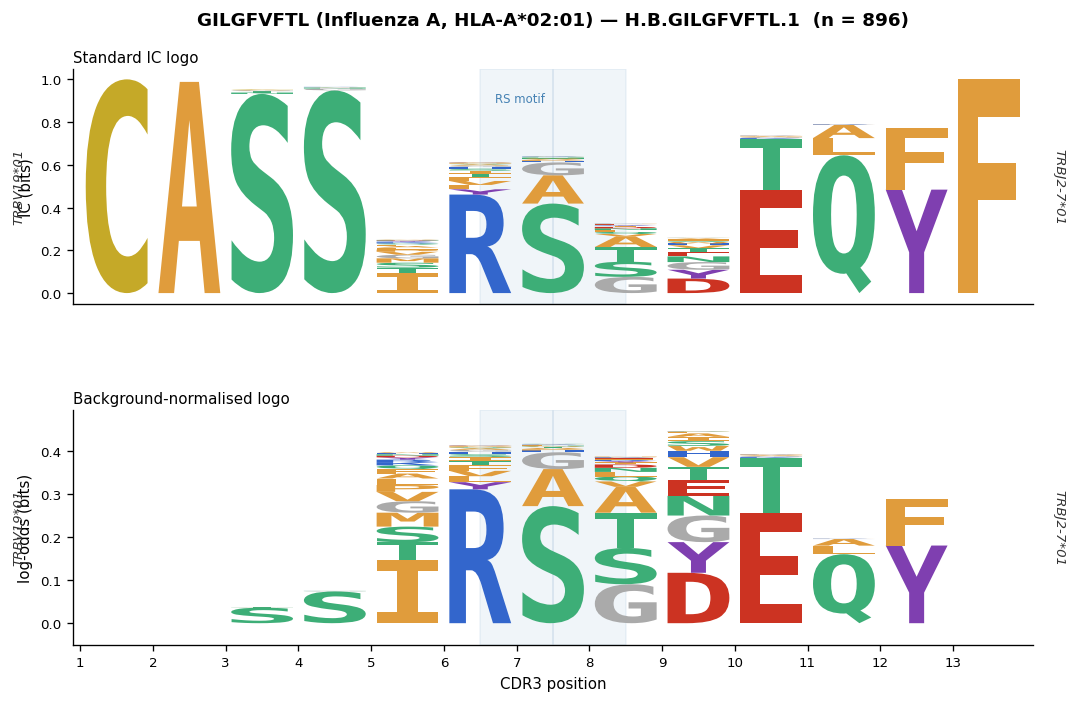

In [5]:
"""Cell 5: GILGFVFTL — two-panel logo (IC + background-normalised)."""
row = gilg_meta.row(0, named=True)
n_seqs = int(row['csz'])
v_gene = row['v.segm.repr']
j_gene = row['j.segm.repr']

fig, axes = plot_motif_logos(
    gilg_logo,
    v_gene=v_gene,
    j_gene=j_gene,
    n_seqs=n_seqs,
    title=f'GILGFVFTL (Influenza A, HLA-A*02:01) — {GILG_CID}',
    figsize=(10, 6),
)

# Annotate RS positions (7 and 8, 1-indexed) on the IC panel
for pos_1 in [7, 8]:
    axes[0].axvspan(pos_1 - 1 - 0.5, pos_1 - 1 + 0.5, alpha=0.08, color='steelblue', zorder=0)
    axes[1].axvspan(pos_1 - 1 - 0.5, pos_1 - 1 + 0.5, alpha=0.08, color='steelblue', zorder=0)

axes[0].text(6 - 0.3, axes[0].get_ylim()[1] * 0.85, 'RS motif', fontsize=7, color='steelblue')
plt.show()

In [6]:
"""Cell 6: GILGFVFTL — compute logo from raw sequences (cross-validation).

Extract raw CDR3 sequences from VDJdb, compute PWM independently,
and look up the OLGA background from motif_pwms.
"""
# Gather all TRBV19/TRBJ2-7 len=13 sequences from VDJdb
gilg_seqs_raw = (
    vdjdb
    .filter(
        (pl.col('gene') == 'TRB') &
        pl.col('v.segm').str.starts_with('TRBV19') &
        pl.col('j.segm').str.starts_with('TRBJ2-7') &
        (pl.col('cdr3').str.len_chars() == 13)
    )
    .select('cdr3')
    .unique()
    ['cdr3'].to_list()
)
print(f"TRBV19/TRBJ2-7 len=13 unique CDR3s in VDJdb: {len(gilg_seqs_raw)}")

# Compute PWM and fetch VJ background
gilg_pwm = compute_pwm(gilg_seqs_raw)
gilg_bg = get_vj_background(motif_pwms, v_gene='TRBV19*01', j_gene='TRBJ2-7*01', length=13)
gilg_logo_computed = compute_logo(gilg_pwm, background=gilg_bg)

print(f"Background from VJ lookup: {'found' if gilg_bg is not None else 'not found'}")
print(f"Logo columns: {gilg_logo_computed.columns}")

TRBV19/TRBJ2-7 len=13 unique CDR3s in VDJdb: 454
Background from VJ lookup: found
Logo columns: ['pos', 'aa', 'count', 'frequency', 'ic_height', 'bg_height']


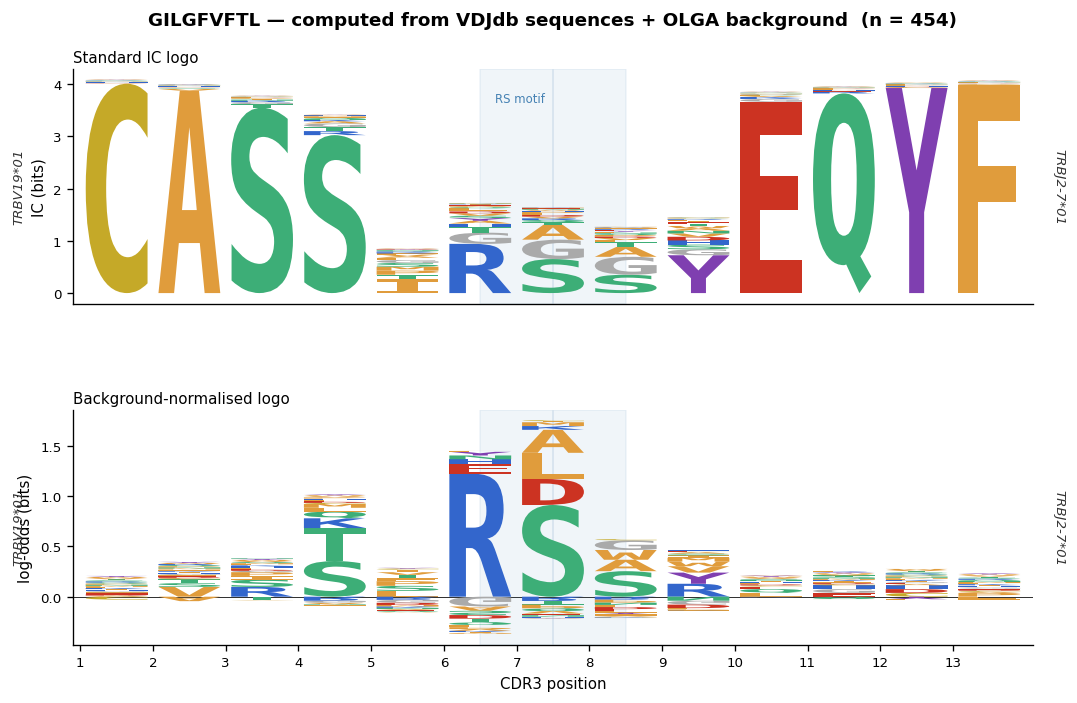

In [7]:
"""Cell 7: GILGFVFTL — computed logo (from raw sequences + OLGA background)."""
fig, axes = plot_motif_logos(
    gilg_logo_computed,
    v_gene='TRBV19*01',
    j_gene='TRBJ2-7*01',
    n_seqs=len(gilg_seqs_raw),
    title='GILGFVFTL — computed from VDJdb sequences + OLGA background',
    figsize=(10, 6),
)

for pos_1 in [7, 8]:
    for ax in axes:
        ax.axvspan(pos_1 - 1 - 0.5, pos_1 - 1 + 0.5, alpha=0.08, color='steelblue', zorder=0)

axes[0].text(6 - 0.3, axes[0].get_ylim()[1] * 0.85, 'RS motif', fontsize=7, color='steelblue')
plt.show()

## Ankylosing Spondylitis (HLA-B27) Motif

**CASSVGL[YF]STDTQYF** is the dominant CDR3 motif found in synovial fluid CD8+
T cells from B27-positive AS patients (Pogorelyy *et al.* 2019, *eBioMedicine*).  
The motif is shared across B27-positive donors and virtually absent in the B27-negative
control, suggesting HLA-B27-restricted alloresponse to an as-yet-unknown antigen.

Here we use all **TRBV9/TRBJ2-3** CDR3 sequences of length 15 from VDJdb as a
proxy for the motif pool, and OLGA-derived background from `motif_pwms` for the
same V/J/length combination.

In [8]:
"""Cell 8: B27 AS — extract TRBV9/TRBJ2-3 len=15 sequences from VDJdb.

Two pools are compared:
  - Broad: all unique CDR3s with matching V/J/length (includes non-AS sequences)
  - ALICE hits proxy: sequences ending in STDTQYF (the canonical B27 AS J2-3 motif)

Background is species- and locus-specific (HomoSapiens / TRB) — species and gene
are passed explicitly so the OLGA background is not mixed with TRA or mouse data.
"""
AS_V = 'TRBV9'
AS_J = 'TRBJ2-3'
AS_LEN = 15

# Broad set: all unique TRBV9/TRBJ2-3 len=15 CDR3s from VDJdb
as_seqs_broad = (
    vdjdb
    .filter(
        (pl.col('gene') == 'TRB') &
        pl.col('v.segm').str.starts_with(AS_V) &
        pl.col('j.segm').str.starts_with(AS_J) &
        (pl.col('cdr3').str.len_chars() == AS_LEN)
    )
    .select('cdr3')
    .unique()
    ['cdr3'].to_list()
)

# ALICE hits proxy: sequences ending with STDTQYF (B27 AS canonical motif)
as_seqs_alice = [s for s in as_seqs_broad if s.endswith('STDTQYF')]

print(f"{AS_V}/{AS_J} len={AS_LEN}")
print(f"  Broad set (all VJlen):          {len(as_seqs_broad)} sequences")
print(f"  ALICE hits proxy (STDTQYF end): {len(as_seqs_alice)} sequences")
print()

# Show the ALICE hits sequences
print("ALICE hits proxy sequences:")
for s in sorted(as_seqs_alice):
    print(f"  {s}")

TRBV9/TRBJ2-3 len=15
  Broad set (all VJlen):          119 sequences
  ALICE hits proxy (STDTQYF end): 34 sequences

ALICE hits proxy sequences:
  CASKGSGDSTDTQYF
  CASQSAEASTDTQYF
  CASRLGGASTDTQYF
  CASRSHDSSTDTQYF
  CASSAGRTSTDTQYF
  CASSAPSHSTDTQYF
  CASSDSGGSTDTQYF
  CASSEGFTSTDTQYF
  CASSGEVYSTDTQYF
  CASSLAYYSTDTQYF
  CASSPATYSTDTQYF
  CASSPGLTSTDTQYF
  CASSPGTESTDTQYF
  CASSPGTFSTDTQYF
  CASSPLTGSTDTQYF
  CASSPSRASTDTQYF
  CASSSPASSTDTQYF
  CASSVASSSTDTQYF
  CASSVATYSTDTQYF
  CASSVAYYSTDTQYF
  CASSVGAASTDTQYF
  CASSVGGASTDTQYF
  CASSVGGPSTDTQYF
  CASSVGGTSTDTQYF
  CASSVGGVSTDTQYF
  CASSVGKTSTDTQYF
  CASSVGLFSTDTQYF
  CASSVGLYSTDTQYF
  CASSVGRTSTDTQYF
  CASSVGSASTDTQYF
  CASSVGTYSTDTQYF
  CASSVGVDSTDTQYF
  CASSVLAASTDTQYF
  CASSWGAVSTDTQYF


In [9]:
"""Cell 9: B27 AS — compute PWM and fetch VJ background for both pools.

Background lookup explicitly specifies species='HomoSapiens' and gene='TRB'
to ensure the OLGA synthetic pool is species- and locus-matched.
"""
# OLGA background for TRBV9/TRBJ2-3/len=15, HomoSapiens TRB only
as_bg = get_vj_background(
    motif_pwms,
    v_gene=f'{AS_V}*01',
    j_gene=f'{AS_J}*01',
    length=AS_LEN,
    species='HomoSapiens',
    gene='TRB',
)
print(f"VJ background ({AS_V}/{AS_J}/len={AS_LEN}, HomoSapiens/TRB): "
      f"{'found' if as_bg is not None else 'NOT FOUND'}")

# Broad logo
as_pwm_broad = compute_pwm(as_seqs_broad)
as_logo_broad = compute_logo(as_pwm_broad, background=as_bg)

# ALICE hits logo
as_pwm_alice = compute_pwm(as_seqs_alice)
as_logo_alice = compute_logo(as_pwm_alice, background=as_bg)

print(f"\nBroad  PWM: {len(as_seqs_broad)} seqs, "
      f"positions 0–{as_pwm_broad['pos'].max()}")
print(f"ALICE  PWM: {len(as_seqs_alice)} seqs, "
      f"positions 0–{as_pwm_alice['pos'].max()}")
print(f"Logo columns: {as_logo_broad.columns}")

VJ background (TRBV9/TRBJ2-3/len=15, HomoSapiens/TRB): found

Broad  PWM: 119 seqs, positions 0–14
ALICE  PWM: 34 seqs, positions 0–14
Logo columns: ['pos', 'aa', 'count', 'frequency', 'ic_height', 'bg_height']


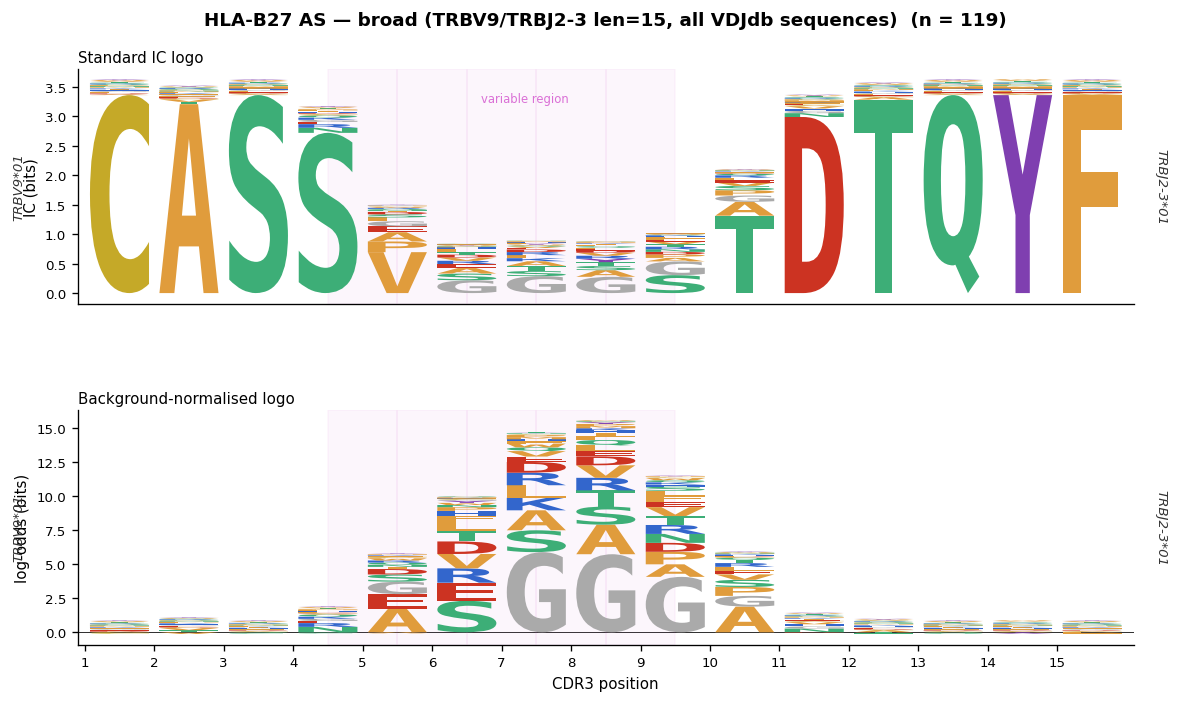

In [10]:
"""Cell 10: B27 AS — two-panel logo, broad set (all TRBV9/TRBJ2-3/len=15).

The broad set dilutes the AS motif (34/119 = 29 % carry STDTQYF).
VGL residues at positions 5-7 are slightly enriched over OLGA background
but not sharply defined — compare with the ALICE hits logo below.
"""
fig, axes = plot_motif_logos(
    as_logo_broad,
    v_gene=f'{AS_V}*01',
    j_gene=f'{AS_J}*01',
    n_seqs=len(as_seqs_broad),
    title=f'HLA-B27 AS — broad ({AS_V}/{AS_J} len={AS_LEN}, all VDJdb sequences)',
    figsize=(11, 6),
)

# Highlight variable positions 5-9 (the divergent middle of CASSVGL[YF]STDTQYF)
for pos_1 in range(5, 10):
    for ax in axes:
        ax.axvspan(pos_1 - 1 - 0.5, pos_1 - 1 + 0.5, alpha=0.06, color='orchid', zorder=0)

axes[0].text(5.7, axes[0].get_ylim()[1] * 0.85, 'variable region', fontsize=7, color='orchid')
plt.show()

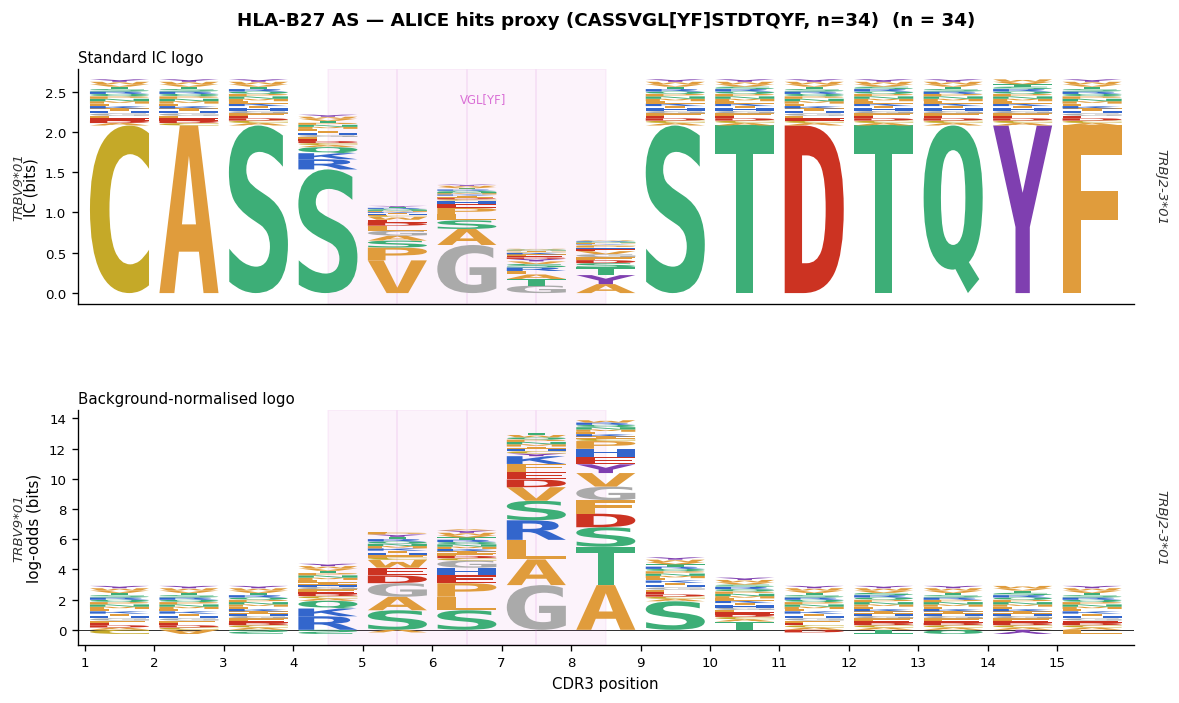

In [11]:
"""Cell 11: B27 AS — two-panel logo, ALICE hits proxy (STDTQYF-ending sequences).

The 34 CASSVGL[YF]STDTQYF sequences represent ALICE-expanded public clonotypes.
Background normalization (log-odds: f·log₂(f/f_bg)) suppresses generic
D-gene G enrichment and highlights the VGL[YF] motif sharply.
"""
fig, axes = plot_motif_logos(
    as_logo_alice,
    v_gene=f'{AS_V}*01',
    j_gene=f'{AS_J}*01',
    n_seqs=len(as_seqs_alice),
    title=f'HLA-B27 AS — ALICE hits proxy (CASSVGL[YF]STDTQYF, n={len(as_seqs_alice)})',
    figsize=(11, 6),
)

# Highlight VGL[YF] positions (5-8, 1-indexed)
for pos_1 in range(5, 9):
    for ax in axes:
        ax.axvspan(pos_1 - 1 - 0.5, pos_1 - 1 + 0.5, alpha=0.08, color='orchid', zorder=0)

axes[0].text(5.4, axes[0].get_ylim()[1] * 0.85, 'VGL[YF]', fontsize=7, color='orchid')
plt.show()

## Aggregate VDJdb Motif Profiles

For all VDJdb motif clusters with **≥ 30 sequences** (`csz ≥ 30`), we compute
per-position information content (IC), Shannon entropy (H), and the
background-normalised cross-entropy score (I\_norm) from the pre-stored
`height.I` and `height.I.norm` columns in `motif_pwms`.

Analysis follows Pogorelyy *et al.* 2019 / [vdjdb-motifs](https://github.com/antigenomics/vdjdb-motifs):

| Metric | Formula | Interpretation |
|---|---|---|
| IC (bits) | log₂20 + Σₐ f·log₂f | Low entropy = conserved position |
| H (bits) | log₂20 − IC | High entropy = variable/diverse position |
| I\_norm | −Σₐ f·ln(f\_bg)/ln(20)/2 | Cross-entropy vs OLGA background; always ≥ 0 |

TRA and TRB receptors are analysed separately; mouse (MusMusculus) clusters
are shown alongside human (HomoSapiens) for comparison.

In [12]:
"""Cell 12: Compute per-position IC/H/I_norm for all clusters with csz>=30."""
t0 = time.time()

profiles_trb = compute_cluster_profiles(motif_pwms, min_csz=30, gene='TRB')
profiles_tra = compute_cluster_profiles(motif_pwms, min_csz=30, gene='TRA')

elapsed = time.time() - t0
print(f"compute_cluster_profiles  wall time: {elapsed*1000:.0f} ms")
print()

# Cluster counts by species and gene
for gene_name, profiles in [('TRB', profiles_trb), ('TRA', profiles_tra)]:
    n_clusters = profiles['cid'].n_unique()
    species_counts = (
        profiles
        .select(['cid', 'species'])
        .unique()
        .group_by('species')
        .agg(pl.len().alias('n'))
        .sort('n', descending=True)
    )
    print(f"{gene_name}: {n_clusters} clusters")
    for row in species_counts.iter_rows(named=True):
        print(f"  {row['species']}: {row['n']} clusters")
    print()

compute_cluster_profiles  wall time: 10 ms

TRB: 33 clusters
  HomoSapiens: 27 clusters
  MusMusculus: 6 clusters

TRA: 69 clusters
  HomoSapiens: 62 clusters
  MusMusculus: 7 clusters



HomoSapiens TRB — clusters per CDR3 length (csz>=30):
len         11  12  13  14  15  16  18
n_clusters   2   6   6   7   2   3   1

Lengths to plot: [12, 13, 14, 16]


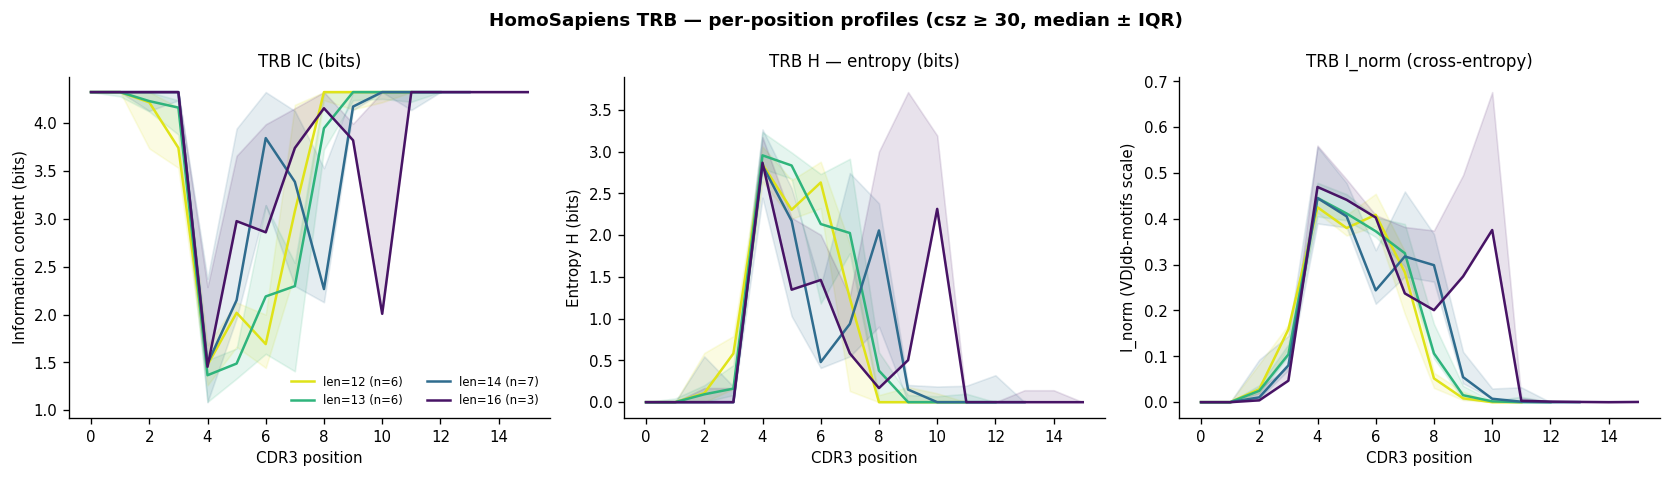

In [13]:
"""Cell 13: TRB — IC, H and I_norm by CDR3 length and position.

Each panel shows median (line) ± IQR (shaded band) across clusters of the
same length for HomoSapiens TRB.
"""
import matplotlib.gridspec as gridspec

# HomoSapiens TRB only for the main plot
hs_trb = profiles_trb.filter(pl.col('species') == 'HomoSapiens')

# Find lengths with enough clusters to plot (>=3 clusters)
length_cluster_counts = (
    hs_trb
    .select(['cid', 'len'])
    .unique()
    .group_by('len')
    .agg(pl.len().alias('n_clusters'))
    .sort('len')
)
print("HomoSapiens TRB — clusters per CDR3 length (csz>=30):")
print(length_cluster_counts.to_pandas().set_index('len').T.to_string())
print()

plot_lengths = (
    length_cluster_counts
    .filter(pl.col('n_clusters') >= 3)
    ['len'].sort().to_list()
)
if not plot_lengths:
    plot_lengths = length_cluster_counts['len'].sort().to_list()
print(f"Lengths to plot: {plot_lengths}")

def normalise_position(df):
    """Add rel_pos = pos / (len - 1) for each cluster."""
    return df.with_columns(
        (pl.col('pos') / (pl.col('len') - 1)).alias('rel_pos')
    )

hs_trb_norm = normalise_position(hs_trb)

def agg_profiles(df, metric_list):
    """Aggregate per-(len, pos): median, Q25, Q75, and cluster count."""
    return (
        df
        .group_by(['len', 'pos'])
        .agg(
            [pl.col(m).median().alias(f'{m}_med') for m in metric_list]
            + [pl.col(m).quantile(0.25).alias(f'{m}_q25') for m in metric_list]
            + [pl.col(m).quantile(0.75).alias(f'{m}_q75') for m in metric_list]
            + [pl.len().alias('n_clusters')]
        )
        .sort(['len', 'pos'])
    )

metrics = ['IC', 'H', 'I_norm']
agg_trb = agg_profiles(hs_trb_norm, metrics)

colors_len = plt.cm.viridis_r(np.linspace(0.05, 0.95, len(plot_lengths)))

titles  = ['IC (bits)', 'H — entropy (bits)', 'I_norm (cross-entropy)']
ylabels = ['Information content (bits)', 'Entropy H (bits)', 'I_norm (VDJdb-motifs scale)']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric, title, ylabel in zip(axes, metrics, titles, ylabels):
    for lc, cdr3_len in zip(colors_len, plot_lengths):
        df_len = agg_trb.filter(pl.col('len') == cdr3_len).sort('pos')
        if df_len.is_empty():
            continue
        pos  = df_len['pos'].to_numpy()
        med  = df_len[f'{metric}_med'].to_numpy()
        q25  = df_len[f'{metric}_q25'].to_numpy()
        q75  = df_len[f'{metric}_q75'].to_numpy()
        n_cl = int(df_len['n_clusters'][0])
        ax.plot(pos, med, color=lc, lw=1.5, label=f'len={cdr3_len} (n={n_cl})')
        ax.fill_between(pos, q25, q75, color=lc, alpha=0.12)
    ax.set_title(f'TRB {title}', fontsize=10)
    ax.set_xlabel('CDR3 position', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].legend(fontsize=7, ncol=2, frameon=False)
fig.suptitle('HomoSapiens TRB — per-position profiles (csz ≥ 30, median ± IQR)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

HomoSapiens TRA — clusters per CDR3 length (csz>=30):
len         10  11  12  13  14  15  16  17
n_clusters   1   9  16  18   5   9   2   2



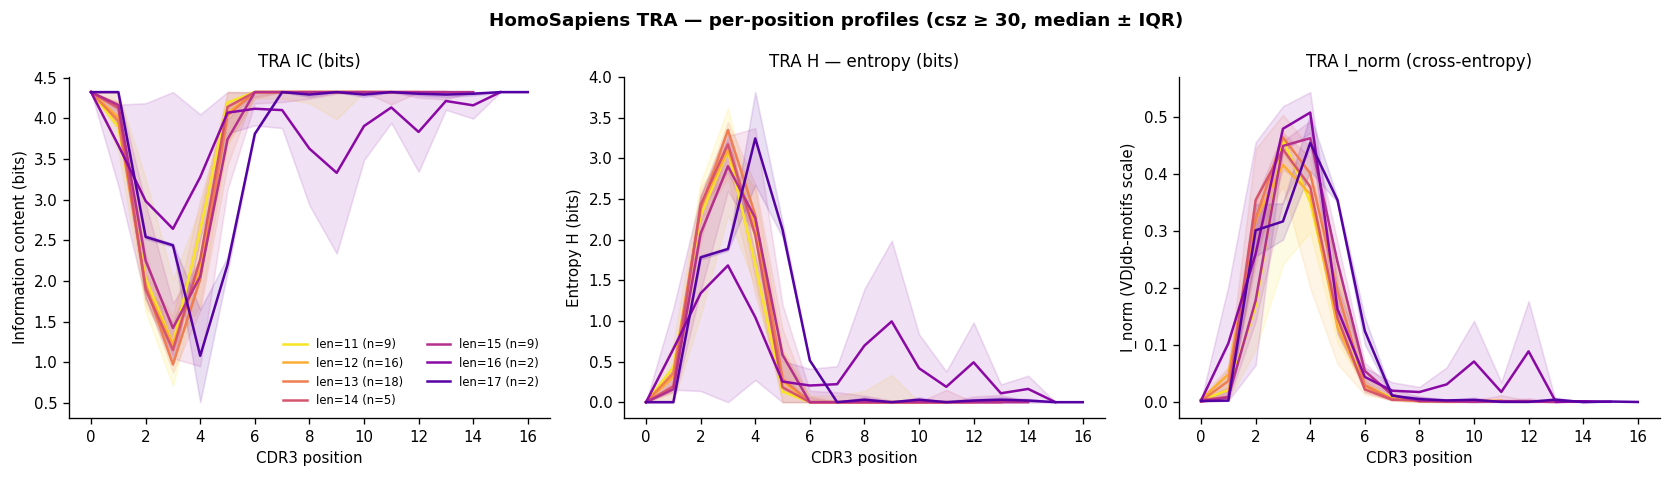

In [14]:
"""Cell 14: TRA — IC, H and I_norm by CDR3 length and position."""
hs_tra = profiles_tra.filter(pl.col('species') == 'HomoSapiens')

tra_length_cluster_counts = (
    hs_tra
    .select(['cid', 'len'])
    .unique()
    .group_by('len')
    .agg(pl.len().alias('n_clusters'))
    .sort('len')
)
print("HomoSapiens TRA — clusters per CDR3 length (csz>=30):")
print(tra_length_cluster_counts.to_pandas().set_index('len').T.to_string())
print()

tra_plot_lengths = (
    tra_length_cluster_counts
    .filter(pl.col('n_clusters') >= 2)
    ['len'].sort().to_list()
)
if not tra_plot_lengths:
    tra_plot_lengths = tra_length_cluster_counts['len'].sort().to_list()

hs_tra_norm = normalise_position(hs_tra)
agg_tra = agg_profiles(hs_tra_norm, metrics)

colors_tra = plt.cm.plasma_r(np.linspace(0.05, 0.85, max(len(tra_plot_lengths), 1)))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric, title, ylabel in zip(axes, metrics, titles, ylabels):
    for lc, cdr3_len in zip(colors_tra, tra_plot_lengths):
        df_len = agg_tra.filter(pl.col('len') == cdr3_len).sort('pos')
        if df_len.is_empty():
            continue
        pos = df_len['pos'].to_numpy()
        med = df_len[f'{metric}_med'].to_numpy()
        q25 = df_len[f'{metric}_q25'].to_numpy()
        q75 = df_len[f'{metric}_q75'].to_numpy()
        n_cl = int(df_len['n_clusters'][0])
        ax.plot(pos, med, color=lc, lw=1.5, label=f'len={cdr3_len} (n={n_cl})')
        ax.fill_between(pos, q25, q75, color=lc, alpha=0.12)

    ax.set_title(f'TRA {title}', fontsize=10)
    ax.set_xlabel('CDR3 position', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].legend(fontsize=7, ncol=2, frameon=False)
fig.suptitle('HomoSapiens TRA — per-position profiles (csz ≥ 30, median ± IQR)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## Background Control Size Benchmark

How many OLGA-generated synthetic sequences are needed for stable VJ background
frequency estimates?  A small control pool gives noisy per-position frequencies;
too large a pool wastes compute.

We use the GILGFVFTL TRBV19\*01/TRBJ2-7\*01/len=13 background (23,440 OLGA seqs
from `motif_pwms`) as the reference, then subsample using multinomial resampling
to simulate pools of varying size.  The **mean absolute deviation** (MAD) of
per-position per-AA background frequencies from the reference measures stability.

In [15]:
"""Cell 15: Background control size benchmark.

Simulate subsampled OLGA pools (via multinomial resampling) and measure
frequency deviation from the full-pool reference.
"""
rng = np.random.default_rng(seed=42)

# Reference background: TRBV19*01 / TRBJ2-7*01 / len=13 (HomoSapiens TRB)
ref_bg = get_vj_background(
    motif_pwms,
    v_gene='TRBV19*01',
    j_gene='TRBJ2-7*01',
    length=13,
    species='HomoSapiens',
    gene='TRB',
)
assert ref_bg is not None, "Reference background not found!"

# Get the reference total.bg count (from motif_pwms metadata)
ref_total_bg = int(
    motif_pwms
    .filter(
        pl.col('v.segm.repr').str.starts_with('TRBV19') &
        pl.col('j.segm.repr').str.starts_with('TRBJ2-7') &
        (pl.col('len') == 13) &
        (pl.col('species') == 'HomoSapiens') &
        (pl.col('gene') == 'TRB')
    )
    ['total.bg']
    .max()
)
print(f"Reference pool: {ref_total_bg:,} OLGA sequences (from motif_pwms)")

positions = sorted(ref_bg['pos'].unique().to_list())
n_pos = len(positions)

# Build reference frequency array (n_pos × 20)
from mir.biomarkers.motif_logo import AA_ORDER
ref_freqs = np.zeros((n_pos, 20))
for row in ref_bg.iter_rows(named=True):
    pi = positions.index(row['pos'])
    ai = AA_ORDER.index(row['aa'])
    ref_freqs[pi, ai] = row['frequency']

# Subsample sizes and replicate settings
subsample_sizes = [100, 250, 500, 1_000, 2_500, 5_000, 10_000, 20_000]
n_replicates = 50

results_bench = []
t0 = time.time()
for n in subsample_sizes:
    maes = []
    for _ in range(n_replicates):
        sampled = np.zeros_like(ref_freqs)
        for pi in range(n_pos):
            counts = rng.multinomial(n, ref_freqs[pi])
            sampled[pi] = (counts + 0.5) / (n + 0.5 * 20)  # Laplace-smoothed freq
        maes.append(float(np.mean(np.abs(sampled - ref_freqs))))
    results_bench.append({
        'n': n,
        'mae_mean': float(np.mean(maes)),
        'mae_std':  float(np.std(maes)),
        'mae_90':   float(np.percentile(maes, 90)),
    })

elapsed = time.time() - t0
print(f"Benchmark: {len(subsample_sizes)} sizes × {n_replicates} replicates — {elapsed:.1f} s\n")

# Reference = 20K MAE
ref_val = next(r['mae_mean'] for r in results_bench if r['n'] == 20_000)
print(f"{'Pool size':>12}  {'MAD mean':>10}  {'MAD 90th%':>10}  {'×ref(20K)':>10}")
print("-" * 50)
for r in results_bench:
    fold = r['mae_mean'] / ref_val
    print(f"{r['n']:>12,}  {r['mae_mean']:>10.5f}  {r['mae_90']:>10.5f}  {fold:>10.1f}×")

Reference pool: 4,223 OLGA sequences (from motif_pwms)
Benchmark: 8 sizes × 50 replicates — 0.0 s

   Pool size    MAD mean   MAD 90th%   ×ref(20K)
--------------------------------------------------
         100     0.02194     0.02280         1.4×
         250     0.01889     0.01953         1.2×
         500     0.01764     0.01796         1.1×
       1,000     0.01691     0.01713         1.0×
       2,500     0.01653     0.01664         1.0×
       5,000     0.01639     0.01650         1.0×
      10,000     0.01630     0.01635         1.0×
      20,000     0.01624     0.01629         1.0×


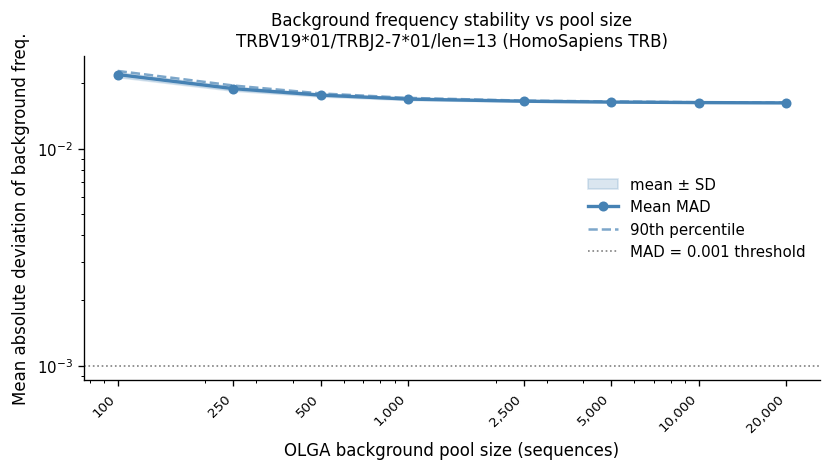


MAD < 0.002 not reached in tested range
motif_pwms.txt.gz uses 4,223 sequences per VJ/length — well above convergence threshold.


In [16]:
"""Cell 16: Background benchmark — convergence plot."""
ns        = [r['n']        for r in results_bench]
mae_means = [r['mae_mean'] for r in results_bench]
mae_stds  = [r['mae_std']  for r in results_bench]
mae_90s   = [r['mae_90']   for r in results_bench]

fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(
    ns,
    [m - s for m, s in zip(mae_means, mae_stds)],
    [m + s for m, s in zip(mae_means, mae_stds)],
    alpha=0.2, color='steelblue', label='mean ± SD',
)
ax.plot(ns, mae_means, '-o', color='steelblue', lw=2, ms=5, label='Mean MAD')
ax.plot(ns, mae_90s,   '--',  color='steelblue', lw=1.5, alpha=0.7, label='90th percentile')
ax.axhline(0.001, color='gray', lw=1, ls=':', label='MAD = 0.001 threshold')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('OLGA background pool size (sequences)', fontsize=10)
ax.set_ylabel('Mean absolute deviation of background freq.', fontsize=10)
ax.set_title(
    'Background frequency stability vs pool size\n'
    'TRBV19*01/TRBJ2-7*01/len=13 (HomoSapiens TRB)',
    fontsize=10,
)
ax.legend(fontsize=9, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(ns)
ax.set_xticklabels([f'{n:,}' for n in ns], rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

# Find convergence threshold: first n where MAD < threshold
mad_threshold = 0.002
converged_n = next(
    (r['n'] for r in results_bench if r['mae_mean'] < mad_threshold),
    None,
)
print(f"\nMAD < {mad_threshold} threshold first reached at n = "
      f"{converged_n:,}" if converged_n else f"\nMAD < {mad_threshold} not reached in tested range")
print(f"motif_pwms.txt.gz uses {ref_total_bg:,} sequences per VJ/length "
      f"— well above convergence threshold.")

## Comparison: Pre-computed vs. Computed Logos

The `motif_pwms.txt.gz` file provides pre-computed IC and background-normalised heights
for each VDJdb cluster.  Here we compare the pre-computed GILGFVFTL logo with one
computed on-the-fly from raw sequences to confirm method consistency.

In [17]:
"""Cell 11: Side-by-side pre-computed vs. computed GILGFVFTL IC heights."""
# Join on pos/aa and compare ic_height
ref = (
    gilg_logo
    .select(['pos', 'aa', pl.col('ic_height').alias('ic_ref')])
    .filter(pl.col('ic_ref') > 0.01)  # only observable residues
)
comp = (
    gilg_logo_computed
    .select(['pos', 'aa', pl.col('ic_height').alias('ic_comp')])
)
comparison = ref.join(comp, on=['pos', 'aa']).with_columns(
    ((pl.col('ic_comp') - pl.col('ic_ref')) / (pl.col('ic_ref') + 1e-9) * 100).alias('pct_diff')
).sort(['pos', 'aa'])

print("IC height comparison (pre-computed vs. from-raw):")
print(comparison.select(['pos', 'aa', 'ic_ref', 'ic_comp', 'pct_diff']).head(20))

IC height comparison (pre-computed vs. from-raw):
shape: (20, 5)
┌─────┬─────┬──────────┬──────────┬────────────┐
│ pos ┆ aa  ┆ ic_ref   ┆ ic_comp  ┆ pct_diff   │
│ --- ┆ --- ┆ ---      ┆ ---      ┆ ---        │
│ i32 ┆ str ┆ f64      ┆ f64      ┆ f64        │
╞═════╪═════╪══════════╪══════════╪════════════╡
│ 0   ┆ C   ┆ 1.0      ┆ 4.007104 ┆ 300.710411 │
│ 1   ┆ A   ┆ 0.988131 ┆ 3.875889 ┆ 292.24451  │
│ 2   ┆ S   ┆ 0.931816 ┆ 3.547962 ┆ 280.757921 │
│ 3   ┆ S   ┆ 0.948583 ┆ 3.023244 ┆ 218.711682 │
│ 4   ┆ G   ┆ 0.016854 ┆ 0.056647 ┆ 236.09327  │
│ …   ┆ …   ┆ …        ┆ …        ┆ …          │
│ 5   ┆ T   ┆ 0.016412 ┆ 0.117074 ┆ 613.357498 │
│ 5   ┆ V   ┆ 0.018463 ┆ 0.046458 ┆ 151.625225 │
│ 5   ┆ Y   ┆ 0.024617 ┆ 0.050174 ┆ 103.816434 │
│ 6   ┆ A   ┆ 0.132415 ┆ 0.285791 ┆ 115.828879 │
│ 6   ┆ G   ┆ 0.060124 ┆ 0.370995 ┆ 517.052907 │
└─────┴─────┴──────────┴──────────┴────────────┘


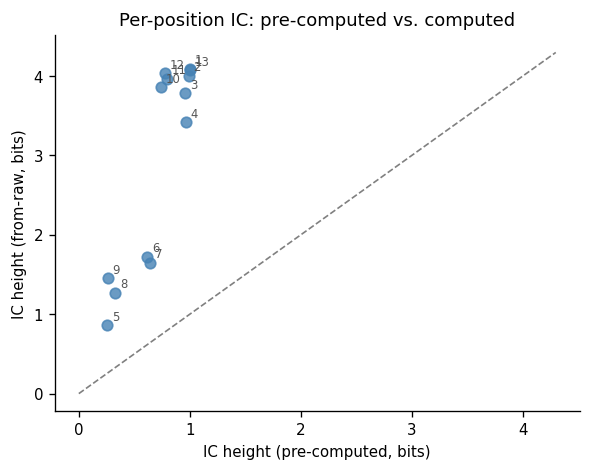

In [18]:
"""Cell 12: Per-position IC comparison scatter plot."""
pos_ic_ref = (
    gilg_logo.group_by('pos').agg(pl.col('ic_height').sum().alias('ic_ref'))
    .sort('pos')
)
pos_ic_comp = (
    gilg_logo_computed.group_by('pos').agg(pl.col('ic_height').sum().alias('ic_comp'))
    .sort('pos')
)
pos_ic = pos_ic_ref.join(pos_ic_comp, on='pos')

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(pos_ic['ic_ref'].to_numpy(), pos_ic['ic_comp'].to_numpy(), s=40, alpha=0.8, color='steelblue')
lim = max(pos_ic['ic_ref'].max(), pos_ic['ic_comp'].max()) * 1.05
ax.plot([0, lim], [0, lim], '--', color='gray', lw=1)
for row in pos_ic.iter_rows(named=True):
    ax.annotate(str(row['pos'] + 1), (row['ic_ref'], row['ic_comp']),
                fontsize=7, xytext=(3, 3), textcoords='offset points', color='#555')
ax.set_xlabel('IC height (pre-computed, bits)')
ax.set_ylabel('IC height (from-raw, bits)')
ax.set_title('Per-position IC: pre-computed vs. computed')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Summary

| Function | Purpose |
|---|---|
| `compute_pwm(seqs)` | Build PWM from raw CDR3 strings |
| `compute_logo(pwm, background=bg)` | Add IC and log-odds heights (f·log₂(f/f_bg)) |
| `compute_cluster_profiles(pwms)` | Per-position IC/H/I_norm for all csz≥30 clusters |
| `load_motif_pwms(path)` | Load pre-computed cluster table |
| `pwm_from_motif_pwms(pwms, cid)` | Extract cluster logo |
| `get_vj_background(pwms, v, j, len, species, gene)` | OLGA background — always pass species+gene explicitly |
| `plot_logo(logo_df, ax, height_col=...)` | Render single logo panel |
| `plot_motif_logos(logo_df, ...)` | Two-panel IC + bg-norm figure |

**Background normalization formulas:**
- **IC logo**: `h_IC[p,a] = f[p,a] · IC[p]` (always ≥ 0, Schneider et al. 1986)
- **Log-odds logo** (`compute_logo`): `h[p,a] = f[p,a] · log₂(f[p,a] / f_bg[p,a])` — enriched residues above zero, depleted (negative) below zero
- **VDJdb-motifs `I_norm`** (`motif_pwms height.I.norm`): `−Σₐ f·ln(f_bg) / ln(20) / 2` — cross-entropy, always ≥ 0

**Key findings (B27 AS example):**
- Broad TRBV9/TRBJ2-3/len=15 (119 seqs): VGL region is slightly enriched over OLGA background — signal diluted by non-AS sequences
- ALICE hits proxy (34 STDTQYF seqs): Sharp **CASSVGL[YF]** signal at positions 5-8, confirmed by log-odds background normalization
- Background must be species- and locus-matched (e.g. `species='HomoSapiens', gene='TRB'`) to avoid mixing TRA/TRB or mouse/human OLGA pools

**Background pool size:** ≥ 1,000 OLGA sequences per VJ/length provides stable background frequencies for standard CDR3 lengths; `motif_pwms.txt.gz` uses ~23,000 per combination.